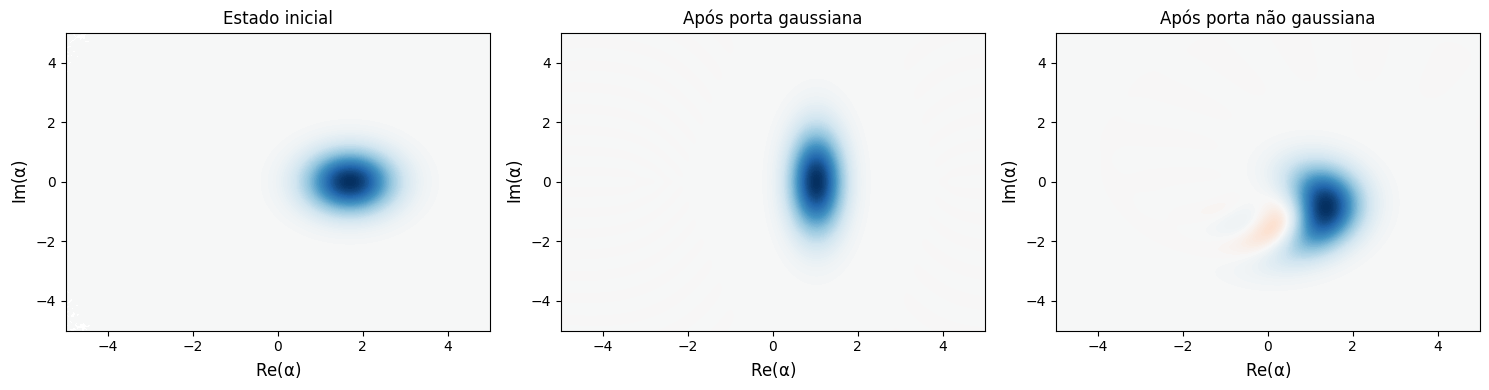

In [2]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt

N = 40
alpha = 1.2

# estado inicial: coerente
psi0 = qt.coherent(N, alpha)

a = qt.destroy(N)
adag = a.dag()
n = adag * a

# Porta gaussiana: squeezing
r = 0.5
G = qt.squeeze(N, r)

# Porta não gaussiana: Kerr
chi = 0.15
K = (-1j * chi * n * n).expm()

psi_g = G * psi0
psi_ng = K * psi0

xvec = np.linspace(-5, 5, 200)

fig, axs = plt.subplots(1, 3, figsize=(15, 4))

qt.plot_wigner(psi0, xvec, xvec, fig=fig, ax=axs[0])
axs[0].set_title("Estado inicial")

qt.plot_wigner(psi_g, xvec, xvec, fig=fig, ax=axs[1])
axs[1].set_title("Após porta gaussiana")

qt.plot_wigner(psi_ng, xvec, xvec, fig=fig, ax=axs[2])
axs[2].set_title("Após porta não gaussiana")

plt.tight_layout()
plt.show()

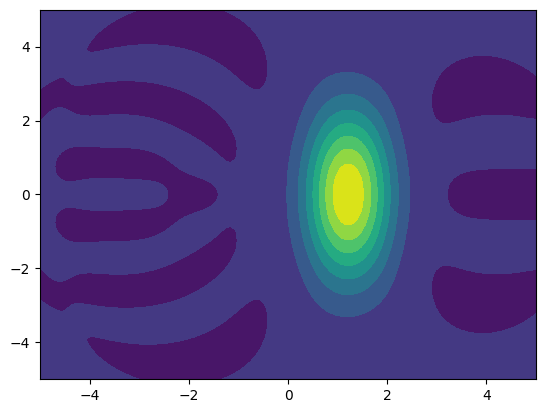

In [3]:
from strawberryfields.ops import Dgate, Sgate
from strawberryfields import Engine, Program
from strawberryfields.backends import FockBackend

import matplotlib.pyplot as plt

eng = Engine("fock", backend_options={"cutoff_dim": 10})
prog = Program(1)

with prog.context as q:
    Dgate(1.0) | q[0]
    Sgate(0.5) | q[0]

state = eng.run(prog).state

# Wigner function
x = p = np.linspace(-5, 5, 100)
W = state.wigner(0, x, p)

plt.contourf(x, p, W)
plt.show()

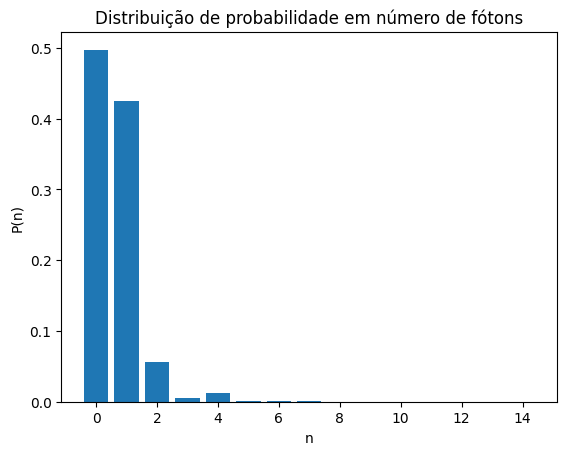

In [4]:
# por modos 
import numpy as np
import matplotlib.pyplot as plt
import strawberryfields as sf
from strawberryfields.ops import Dgate, Sgate

cutoff = 15

prog = sf.Program(1)
eng = sf.Engine("fock", backend_options={"cutoff_dim": cutoff})

with prog.context as q:
    Dgate(1.0) | q[0]
    Sgate(0.4) | q[0]

state = eng.run(prog).state

# probs[n] = P(n fótons)
probs = state.all_fock_probs()   # shape: (cutoff,)
n = np.arange(len(probs))

plt.bar(n, probs)
plt.xlabel("n")
plt.ylabel("P(n)")
plt.title("Distribuição de probabilidade em número de fótons")
plt.show()

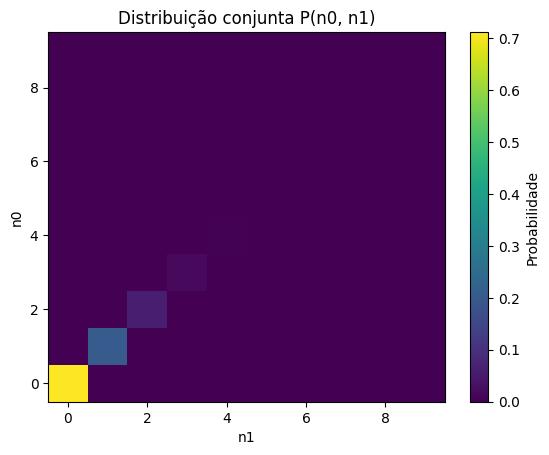

In [5]:
# por estado de fock
import numpy as np
import matplotlib.pyplot as plt
import strawberryfields as sf
from strawberryfields.ops import S2gate

cutoff = 10

prog = sf.Program(2)
eng = sf.Engine("fock", backend_options={"cutoff_dim": cutoff})

with prog.context as q:
    S2gate(0.6) | (q[0], q[1])

state = eng.run(prog).state
probs = state.all_fock_probs()   # shape: (cutoff, cutoff)

plt.imshow(probs, origin="lower", aspect="auto")
plt.colorbar(label="Probabilidade")
plt.xlabel("n1")
plt.ylabel("n0")
plt.title("Distribuição conjunta P(n0, n1)")
plt.show()

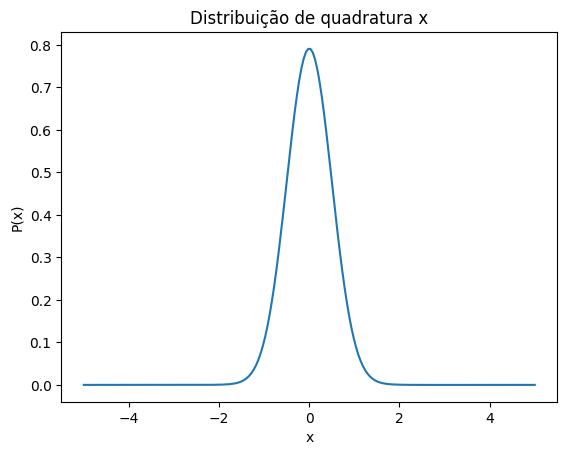

In [6]:
# por quadratura
import numpy as np
import matplotlib.pyplot as plt
import strawberryfields as sf
from strawberryfields.ops import Sgate

cutoff = 20
prog = sf.Program(1)
eng = sf.Engine("fock", backend_options={"cutoff_dim": cutoff})

with prog.context as q:
    Sgate(0.7) | q[0]

state = eng.run(prog).state

xvec = np.linspace(-5, 5, 200)
pvec = np.linspace(-5, 5, 200)

px = state.x_quad_values(0, xvec, pvec)

plt.plot(xvec, px)
plt.xlabel("x")
plt.ylabel("P(x)")
plt.title("Distribuição de quadratura x")
plt.show()